# Speaker Verification: ResNet-50 (Cosine Contrastive Loss, 5s Audio)\n

In [1]:
import os
import pandas as pd
import numpy as np

DATASET_ROOT   = "/kaggle/input/datasets/tahmidulislamomi/ml-project-openslr-dataset"
BASE_AUDIO_DIR = os.path.join(DATASET_ROOT, "train-clean-100", "train-clean-100")
TRAIN_CSV      = os.path.join(DATASET_ROOT, "train_pairs.csv")

# Test dataset paths
TEST_ROOT      = "/kaggle/input/datasets/tahmidulislamomi/ml-project-testing-dataset"
TEST_AUDIO_DIR = os.path.join(TEST_ROOT, "test-clean")
TEST_CSV       = os.path.join(TEST_ROOT, "test_pairs.csv")

print("Train audio dir:", BASE_AUDIO_DIR)
print("Test  audio dir:", TEST_AUDIO_DIR)

Train audio dir: /kaggle/input/datasets/tahmidulislamomi/ml-project-openslr-dataset/train-clean-100/train-clean-100
Test  audio dir: /kaggle/input/datasets/tahmidulislamomi/ml-project-testing-dataset/test-clean


## 2. Load Training & Test DataFrames

In [2]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

def to_train_abs(rel):
    return os.path.join(BASE_AUDIO_DIR, rel.replace("train-clean-100/", "", 1))

def to_test_abs(rel):
    return os.path.join(TEST_AUDIO_DIR, rel)

train_df["path1_abs"] = train_df["audio_path_1"].apply(to_train_abs)
train_df["path2_abs"] = train_df["audio_path_2"].apply(to_train_abs)

test_df["path1_abs"]  = test_df["audio_path_1"].apply(to_test_abs)
test_df["path2_abs"]  = test_df["audio_path_2"].apply(to_test_abs)

print("Train rows:", len(train_df), "| Label dist:")
print(train_df["label"].value_counts().to_dict())
print("Test rows:", len(test_df))

Train rows: 50000 | Label dist:
{1: 25000, 0: 25000}
Test rows: 50000


## 3. Audio Transforms — 5-Second Window

`TARGET_LENGTH = 16000 * 5 = 80000 samples`

- **Training** → fixed 5s window (random crop or padding to 5s)
- **Evaluation** → dynamic window (center crop to 5s if longer, **NO padding** if shorter)

In [3]:
import torch
import numpy as np
import torchaudio.transforms as T

TARGET_SR     = 16000
TARGET_LENGTH = TARGET_SR * 5   # 80000 samples (5 seconds)

def crop_or_pad(audio, is_train=True):
    length = len(audio)
    if length > TARGET_LENGTH:
        if is_train:
            start = np.random.randint(0, length - TARGET_LENGTH)
        else:
            start = (length - TARGET_LENGTH) // 2   # center crop
        audio = audio[start:start + TARGET_LENGTH]
    elif length < TARGET_LENGTH:
        if is_train:
            # Training: pad to fixed 5s for batching
            audio = np.pad(audio, (0, TARGET_LENGTH - length), mode='constant')
        # Testing: Keep dynamic length (no padding)
    return audio

mel_transform   = T.MelSpectrogram(sample_rate=16000, n_fft=400, hop_length=160, n_mels=80)
amplitude_to_db = T.AmplitudeToDB()
print("Transforms ready. Training: fixed 5s | Testing: dynamic up to 5s")

Transforms ready. Training: fixed 5s | Testing: dynamic up to 5s


## 4. SpeakerPairDataset

In [4]:
import soundfile as sf
from torch.utils.data import Dataset

class SpeakerPairDataset(Dataset):
    def __init__(self, dataframe, mel_transform, amplitude_to_db, is_train=True):
        self.df              = dataframe
        self.mel_transform   = mel_transform
        self.amplitude_to_db = amplitude_to_db
        self.is_train        = is_train

    def __len__(self):
        return len(self.df)

    def load_audio(self, path):
        audio, sr = sf.read(path)
        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)
        audio = crop_or_pad(audio, is_train=self.is_train)
        audio = torch.tensor(audio).float().unsqueeze(0)
        return self.amplitude_to_db(self.mel_transform(audio))

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        mel1  = self.load_audio(row["path1_abs"])
        mel2  = self.load_audio(row["path2_abs"])
        label = torch.tensor(row["label"]).float()
        return mel1, mel2, label

## 5. Initialize Datasets & DataLoaders

In [5]:
from torch.utils.data import DataLoader

train_dataset = SpeakerPairDataset(train_df, mel_transform, amplitude_to_db, is_train=True)
test_dataset  = SpeakerPairDataset(test_df,  mel_transform, amplitude_to_db, is_train=False)

# Batch size for ResNet50 on 5s clips (64 for stability)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)

# Test Loader: Batch size = 1 is REQUIRED for dynamic length evaluation
# (Spectrograms of different lengths cannot be stacked into a single tensor batch)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train dataset: {len(train_dataset):,} pairs | {len(train_loader):,} batches (BS=64)")
print(f"Test dataset:  {len(test_dataset):,} pairs  | {len(test_loader):,} batches (BS=1)")

Train dataset: 50,000 pairs | 782 batches (BS=64)
Test dataset:  50,000 pairs  | 50,000 batches (BS=1)


## 6. Model Architecture — ResNetSpeaker (ResNet50)

In [6]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class ResNetSpeaker(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.backbone = models.resnet50(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.embedding = nn.Linear(in_features, embedding_dim)

    def forward(self, x):
        features  = self.backbone(x)
        embedding = self.embedding(features)
        return F.normalize(embedding, p=2, dim=1)   # L2 normalize → cosine = dot product

## 7. Cosine Contrastive Loss

Instead of Euclidean distance, uses **Cosine Similarity** directly in the contrastive formula:
- Same speaker (`label=1`): maximise similarity → push toward **+1.0**
- Different speaker (`label=0`): minimise similarity → push toward **0.0** (or below, clamped)

`margin=0.5` means: different-speaker pairs must have cosine similarity < 0.5 to incur no penalty.

In [7]:
class CosineContrastiveLoss(nn.Module):
    def __init__(self, margin=0.5):
        super().__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        similarity = F.cosine_similarity(emb1, emb2)

        # Pull: same speaker → similarity should be 1.0
        pos_loss = label * torch.pow(1.0 - similarity, 2)

        # Push: different speaker → similarity should be below margin
        neg_loss = (1 - label) * torch.pow(torch.clamp(similarity - self.margin, min=0.0), 2)

        return torch.mean(pos_loss + neg_loss)

## 8. Training Configuration

In [8]:
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = ResNetSpeaker(embedding_dim=256).to(device)
criterion = CosineContrastiveLoss(margin=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Device:", device)
print("Loss:   CosineContrastiveLoss (margin=0.5)")
print("Optim:  Adam (lr=1e-3)")

Device: cuda
Loss:   CosineContrastiveLoss (margin=0.5)
Optim:  Adam (lr=1e-3)


## 9. Training Loop — 25 Epochs

Why 25 epochs instead of 30?
5-second clips create larger spectrograms (~150% frequency bins), so each epoch takes longer.
25 epochs gives the same approximate compute budget.

Auto-saves checkpoint after **every epoch** to protect against Kaggle 12-hour timeout.

In [9]:
from tqdm import tqdm

NUM_EPOCHS  = 25
PRINT_EVERY = 50

loss_history      = []
train_acc_history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss    = 0
    total_correct = 0
    total_samples = 0

    bar = tqdm(enumerate(train_loader), total=len(train_loader),
               desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for batch_idx, (mel1, mel2, labels) in bar:
        mel1   = mel1.to(device)
        mel2   = mel2.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        emb1 = model(mel1)
        emb2 = model(mel2)

        loss = criterion(emb1, emb2, labels)
        loss.backward()
        optimizer.step()

        # Accuracy: cosine_sim > 0.5 → same speaker
        with torch.no_grad():
            sim   = F.cosine_similarity(emb1, emb2)
            preds = (sim > 0.5).float()
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss += loss.item()
        bar.set_postfix(loss=f"{loss.item():.4f}")

        if batch_idx % PRINT_EVERY == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    avg_acc  = total_correct / total_samples

    loss_history.append(avg_loss)
    train_acc_history.append(avg_acc)

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] — Avg Loss: {avg_loss:.4f} | Train Acc: {avg_acc:.4f}\n")

    # ── Auto-save every epoch ──────────────────────────────────────────────────
    torch.save({
        "model_state":        model.state_dict(),
        "epoch":              epoch,
        "optimizer_state":    optimizer.state_dict(),
        "loss_history":       loss_history,
        "train_acc_history":  train_acc_history,
    }, "checkpoint_resnet50_cosine5s.pth")
    print(f"  Checkpoint saved → epoch {epoch+1}")

print("\nTraining complete!")

Epoch 1/25:   0%|          | 1/782 [00:05<1:16:37,  5.89s/it, loss=0.1007]

Epoch 1 | Batch 0/782 | Loss: 0.1007


Epoch 1/25:   7%|▋         | 51/782 [02:02<25:08,  2.06s/it, loss=0.0436]

Epoch 1 | Batch 50/782 | Loss: 0.0436


Epoch 1/25:  13%|█▎        | 101/782 [04:03<14:33,  1.28s/it, loss=0.0560]

...

Epoch 25 | Batch 700/782 | Loss: 0.0026


Epoch 25/25:  96%|█████████▌| 751/782 [14:32<00:35,  1.16s/it, loss=0.0015]

Epoch 25 | Batch 750/782 | Loss: 0.0015


Epoch 25/25: 100%|██████████| 782/782 [15:07<00:00,  1.16s/it, loss=0.0032]



Epoch [25/25] — Avg Loss: 0.0023 | Train Acc: 0.9562

  Checkpoint saved → epoch 25

Training complete!


## 10. Final Model Save

In [10]:
torch.save({
    "model_state":       model.state_dict(),
    "epoch":             NUM_EPOCHS - 1,
    "optimizer_state":   optimizer.state_dict(),
    "loss_history":      loss_history,
    "train_acc_history": train_acc_history,
}, "checkpoint_resnet50_cosine5s.pth")

print("Final model saved → checkpoint_resnet50_cosine5s.pth")

Final model saved → checkpoint_resnet50_cosine5s.pth


## 11. Training History Graphs — Loss & Accuracy per Epoch

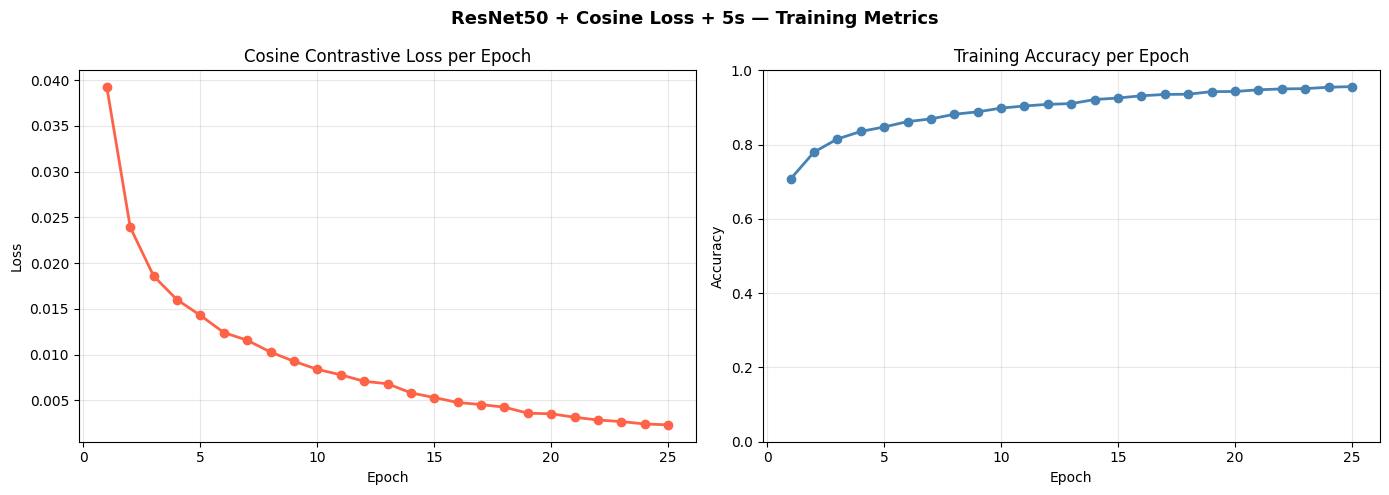

Saved → training_metrics_cosine5s.png


In [11]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(loss_history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ResNet50 + Cosine Loss + 5s — Training Metrics", fontsize=13, fontweight='bold')

axes[0].plot(epochs_range, loss_history, marker='o', color='tomato', linewidth=2)
axes[0].set_title("Cosine Contrastive Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, train_acc_history, marker='o', color='steelblue', linewidth=2)
axes[1].set_title("Training Accuracy per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_metrics_cosine5s.png", dpi=150)
plt.show()
print("Saved → training_metrics_cosine5s.png")

## 12. Evaluate Function

Uses **cosine similarity > 0.5** (same threshold as the loss margin) to predict Same/Different.

In [12]:
def evaluate(model, loader, device, label_name="Set"):
    model.eval()
    correct = 0; total = 0
    same_sims, diff_sims = [], []
    same_dists, diff_dists = [], []

    with torch.no_grad():
        for mel1, mel2, labels in tqdm(loader, desc=f"Evaluating {label_name}"):
            mel1   = mel1.to(device)
            mel2   = mel2.to(device)
            labels = labels.to(device)

            emb1 = model(mel1)
            emb2 = model(mel2)

            sim   = F.cosine_similarity(emb1, emb2)
            preds = (sim > 0.5).float()
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            # Collect similarity & distance for plots
            for s, lbl in zip(sim.cpu().tolist(), labels.cpu().tolist()):
                (same_sims if lbl == 1 else diff_sims).append(s)

            d = F.pairwise_distance(emb1, emb2).cpu().tolist()
            for dist, lbl in zip(d, labels.cpu().tolist()):
                (same_dists if lbl == 1 else diff_dists).append(dist)

    acc = correct / total
    print(f"{label_name} Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    return acc, same_sims, diff_sims, same_dists, diff_dists

## 13. Run Evaluation on Training Set & Test Set

In [13]:
train_acc, tr_same_sim, tr_diff_sim, tr_same_d, tr_diff_d = evaluate(
    model, train_loader, device, "Training Set"
)
test_acc,  te_same_sim, te_diff_sim, te_same_d, te_diff_d = evaluate(
    model, test_loader,  device, "Test Set"
)

print(f"\nTrain Acc: {train_acc*100:.2f}%  |  Test Acc: {test_acc*100:.2f}%")
print(f"Generalisation Gap: {(train_acc - test_acc)*100:.2f}%")

Evaluating Training Set: 100%|██████████| 782/782 [07:15<00:00,  1.80it/s]


Training Set Accuracy: 0.9566 (95.66%)


Evaluating Test Set: 100%|██████████| 50000/50000 [13:12<00:00, 63.08it/s]

Test Set Accuracy: 0.8678 (86.78%)

Train Acc: 95.66%  |  Test Acc: 86.78%
Generalisation Gap: 8.87%


## 14. Accuracy Comparison Bar Chart

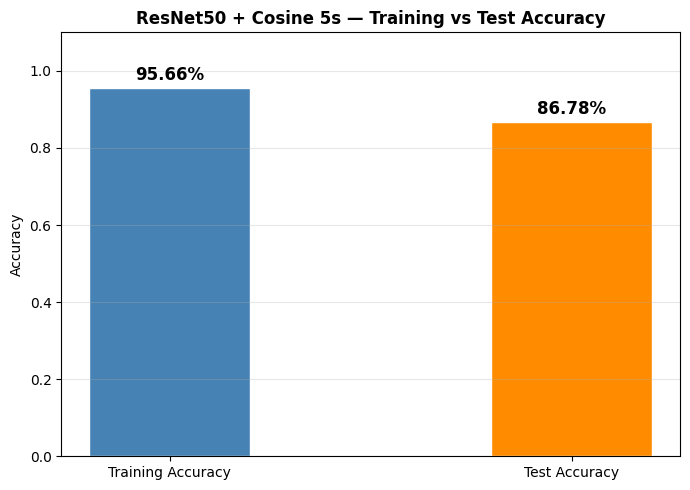

Saved → accuracy_comparison_cosine5s.png


In [14]:
plt.figure(figsize=(7, 5))
bars  = plt.bar(["Training Accuracy", "Test Accuracy"],
                [train_acc, test_acc],
                color=["steelblue", "darkorange"], width=0.4, edgecolor='white')
for bar, val in zip(bars, [train_acc, test_acc]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val*100:.2f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("ResNet50 + Cosine 5s — Training vs Test Accuracy", fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_comparison_cosine5s.png", dpi=150)
plt.show()
print("Saved → accuracy_comparison_cosine5s.png")

## 15. Cosine Similarity Distribution — Training vs Test

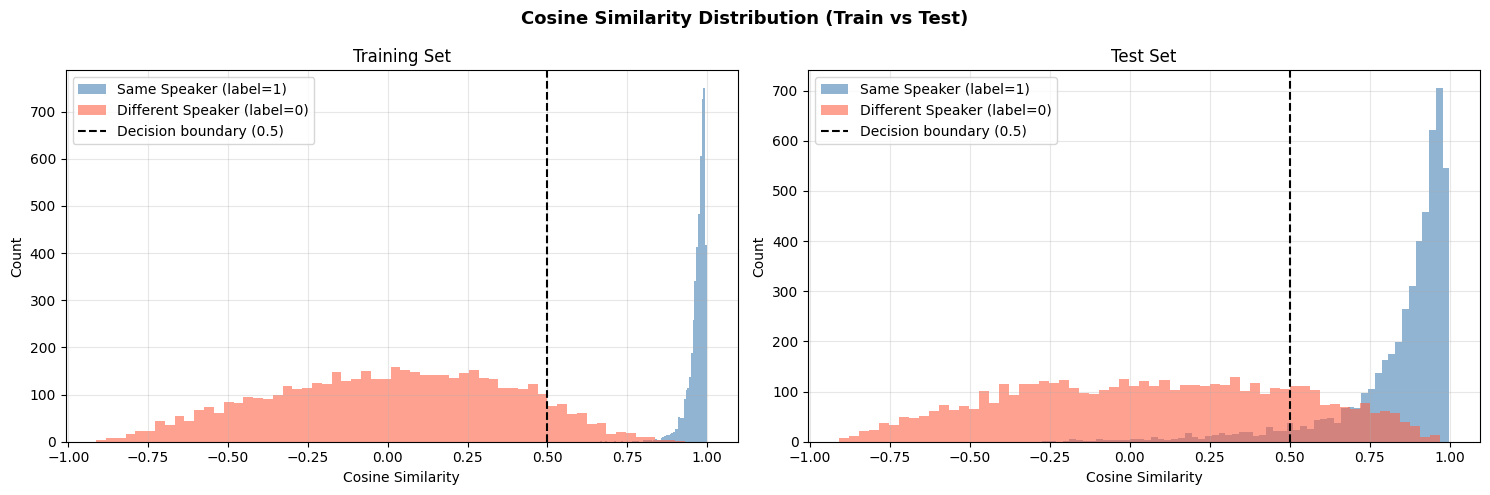

Saved → cosine_sim_distribution_5s.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Cosine Similarity Distribution (Train vs Test)", fontsize=13, fontweight='bold')

for ax, same, diff, title in [
    (axes[0], tr_same_sim[:5000], tr_diff_sim[:5000], "Training Set"),
    (axes[1], te_same_sim[:5000], te_diff_sim[:5000], "Test Set"),
]:
    ax.hist(same, bins=60, alpha=0.6, color='steelblue', label='Same Speaker (label=1)')
    ax.hist(diff, bins=60, alpha=0.6, color='tomato',    label='Different Speaker (label=0)')
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Decision boundary (0.5)')
    ax.set_title(title)
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Count")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cosine_sim_distribution_5s.png", dpi=150)
plt.show()
print("Saved → cosine_sim_distribution_5s.png")

## 16. Euclidean Distance Distribution — Training vs Test

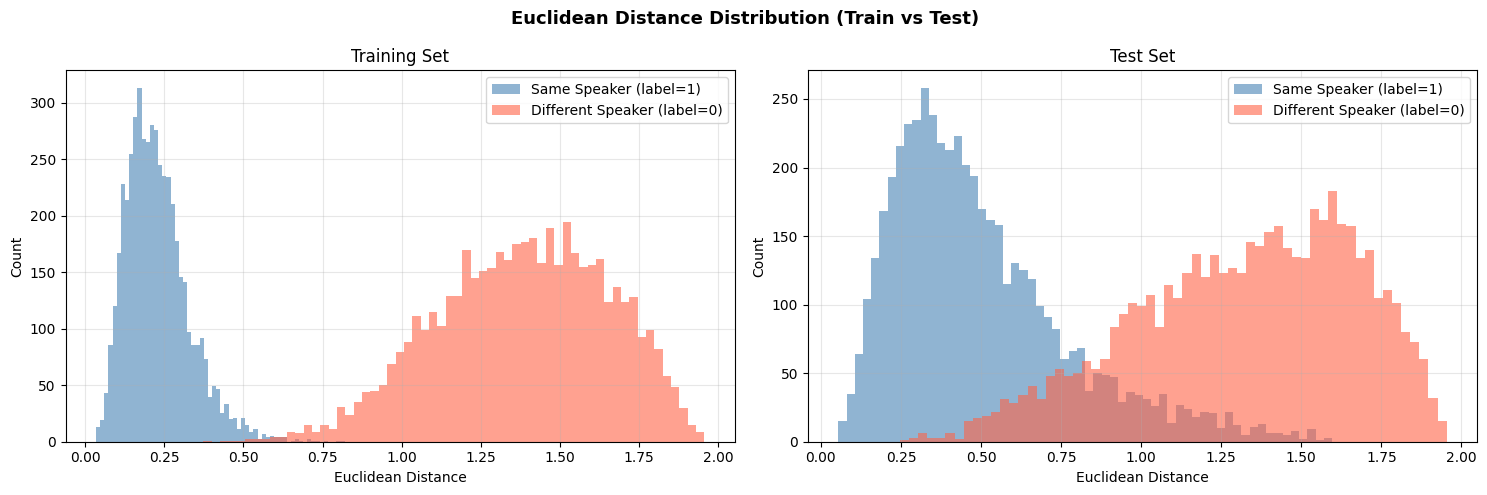

Saved → euclidean_dist_distribution_5s.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Euclidean Distance Distribution (Train vs Test)", fontsize=13, fontweight='bold')

for ax, same, diff, title in [
    (axes[0], tr_same_d[:5000], tr_diff_d[:5000], "Training Set"),
    (axes[1], te_same_d[:5000], te_diff_d[:5000], "Test Set"),
]:
    ax.hist(same, bins=60, alpha=0.6, color='steelblue', label='Same Speaker (label=1)')
    ax.hist(diff, bins=60, alpha=0.6, color='tomato',    label='Different Speaker (label=0)')
    ax.set_title(title)
    ax.set_xlabel("Euclidean Distance")
    ax.set_ylabel("Count")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("euclidean_dist_distribution_5s.png", dpi=150)
plt.show()
print("Saved → euclidean_dist_distribution_5s.png")

## 17. Final Summary

In [17]:
print("=" * 45)
print("  MODEL:  ResNet50 + Cosine Contrastive Loss")
print("  AUDIO:  5-second clips (80000 samples)")
print("-" * 45)
print(f"  Training Accuracy : {train_acc*100:.2f}%")
print(f"  Test Accuracy     : {test_acc*100:.2f}%")
print(f"  Generalisation Gap: {(train_acc - test_acc)*100:.2f}%")
print("=" * 45)
print("Saved files:")
print("  checkpoint_resnet50_cosine5s.pth")
print("  training_metrics_cosine5s.png")
print("  accuracy_comparison_cosine5s.png")
print("  cosine_sim_distribution_5s.png")
print("  euclidean_dist_distribution_5s.png")

  MODEL:  ResNet50 + Cosine Contrastive Loss
  AUDIO:  5-second clips (80000 samples)
---------------------------------------------
  Training Accuracy : 95.66%
  Test Accuracy     : 86.78%
  Generalisation Gap: 8.87%
Saved files:
  checkpoint_resnet50_cosine5s.pth
  training_metrics_cosine5s.png
  accuracy_comparison_cosine5s.png
  cosine_sim_distribution_5s.png
  euclidean_dist_distribution_5s.png
